In [6]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

In [2]:
np.random.seed(1)

#### Stroop Experiment

In [10]:
# Simulation parameters

n_participants = 30

n_trials = 20

grand_mean = 650

participant_sd = 60

trial_sd = 30

# Simulating participant-specific condition effects.

neutral_effects = np.random.normal(
    loc=25,
    scale=5,
    size=n_participants
)

incongruent_effects = np.random.normal(
    loc=80,
    scale=10,
    size=n_participants
)

In [4]:
# Simulating participant baselines.

participant_intercepts = np.random.normal(
    loc=grand_mean,
    scale=participant_sd,
    size=n_participants
)

In [13]:
# Simulating repeated observations.

participant = []

condition = []

reaction_time = []

for i in range(n_participants):

    baseline = participant_intercepts[i]

    # Congruent
    rt = np.random.normal(
        loc=baseline,
        scale=trial_sd,
        size=n_trials
    )

    participant.extend([i + 1] * n_trials)
    condition.extend(["Congruent"] * n_trials)
    reaction_time.extend(rt)

    # Neutral
    rt = np.random.normal(
        loc=baseline + neutral_effects[i],
        scale=trial_sd,
        size=n_trials
    )

    participant.extend([i + 1] * n_trials)
    condition.extend(["Neutral"] * n_trials)
    reaction_time.extend(rt)

    # Incongruent
    rt = np.random.normal(
        loc=baseline + incongruent_effects[i],
        scale=trial_sd,
        size=n_trials
    )

    participant.extend([i + 1] * n_trials)
    condition.extend(["Incongruent"] * n_trials)
    reaction_time.extend(rt)

data = pd.DataFrame({
    "participant": participant,
    "condition": condition,
    "reaction_time": reaction_time
})

print(data.head())

   participant  condition  reaction_time
0            1  Congruent     746.562646
1            1  Congruent     726.192620
2            1  Congruent     742.653578
3            1  Congruent     769.129126
4            1  Congruent     687.497803


In [14]:
# Candidate Model 1: OLS

ols_model = smf.ols(
    "reaction_time ~ C(condition)",
    data=data
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:          reaction_time   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.199
Method:                 Least Squares   F-statistic:                     224.5
Date:                Sun, 19 Jul 2026   Prob (F-statistic):           9.13e-88
Time:                        15:40:59   Log-Likelihood:                -10139.
No. Observations:                1800   AIC:                         2.028e+04
Df Residuals:                    1797   BIC:                         2.030e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [15]:
# Candidate Model 2: Random Intercept

random_intercept_model = smf.mixedlm(
    "reaction_time ~ C(condition)",
    data=data,
    groups=data["participant"]
).fit()

print(random_intercept_model.summary())

                  Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      reaction_time
No. Observations:      1800         Method:                  REML         
No. Groups:            30           Scale:                   899.7797     
Min. group size:       60           Log-Likelihood:          -8751.4736   
Max. group size:       60           Converged:               Yes          
Mean group size:       60.0                                               
--------------------------------------------------------------------------
                             Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------
Intercept                    644.487   11.321 56.928 0.000 622.298 666.676
C(condition)[T.Incongruent]   81.467    1.732 47.041 0.000  78.073  84.861
C(condition)[T.Neutral]       27.937    1.732 16.132 0.000  24.543  31.332
Group Var                   3799.999   33.66

In [16]:
# Candidate Model 3: Random Intercept + Random Slope

random_intercept_slope_model = smf.mixedlm(
    "reaction_time ~ C(condition)",
    data=data,
    groups=data["participant"],
    re_formula="~C(condition)"
).fit()

print(random_intercept_slope_model.summary())

                                 Mixed Linear Model Regression Results
Model:                           MixedLM                Dependent Variable:                reaction_time
No. Observations:                1800                   Method:                            REML         
No. Groups:                      30                     Scale:                             880.3801     
Min. group size:                 60                     Log-Likelihood:                    -8743.8338   
Max. group size:                 60                     Converged:                         Yes          
Mean group size:                 60.0                                                                   
--------------------------------------------------------------------------------------------------------
                                                           Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
-----------------------------------------------------------------------------------------

In [60]:
# Comparing the models.

print("AIC Comparison")

print("OLS:", ols_model.aic)

print("Random intercept:", random_intercept_model.aic)

print("Random intercept + slope:", random_intercept_slope_model.aic)

AIC Comparison
OLS: 4461.200413809605
Random intercept: nan
Random intercept + slope: nan


#### Lexical Decision Experiment

In [20]:
# Simulation parameters

n_participants = 40

n_words = 80

grand_mean = 700

participant_sd = 60

word_sd = 35

trial_sd = 25

In [21]:
# Simulating participant and word effects.

participant_intercepts = np.random.normal(
    loc=0,
    scale=participant_sd,
    size=n_participants
)

word_intercepts = np.random.normal(
    loc=0,
    scale=word_sd,
    size=n_words
)

word_frequency = np.random.choice(
    ["High", "Low"],
    size=n_words
)

frequency_effect = {
    "High": -40,
    "Low": 0
}

In [22]:
# Simulating observations.

participant = []

word = []

frequency = []

reaction_time = []

for i in range(n_participants):

    for j in range(n_words):

        mean_rt = (
            grand_mean
            + participant_intercepts[i]
            + word_intercepts[j]
            + frequency_effect[word_frequency[j]]
        )

        rt = np.random.normal(
            loc=mean_rt,
            scale=trial_sd
        )

        participant.append(i + 1)

        word.append(j + 1)

        frequency.append(word_frequency[j])

        reaction_time.append(rt)

data = pd.DataFrame({
    "participant": participant,
    "word": word,
    "frequency": frequency,
    "reaction_time": reaction_time
})

print(data.head())

   participant  word frequency  reaction_time
0            1     1      High     587.091585
1            1     2      High     608.012071
2            1     3       Low     692.764202
3            1     4       Low     575.675853
4            1     5       Low     700.197257


In [23]:
# Model 1: OLS

ols_model = smf.ols(
    "reaction_time ~ C(frequency)",
    data=data
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:          reaction_time   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.145
Method:                 Least Squares   F-statistic:                     542.3
Date:                Sun, 19 Jul 2026   Prob (F-statistic):          6.11e-111
Time:                        15:45:55   Log-Likelihood:                -18119.
No. Observations:                3200   AIC:                         3.624e+04
Df Residuals:                    3198   BIC:                         3.625e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             644.9284    

In [24]:
# Model 2: Random Intercepts for Participants

participant_model = smf.mixedlm(
    "reaction_time ~ C(frequency)",
    data=data,
    groups=data["participant"]
).fit()

print(participant_model.summary())

              Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   reaction_time
No. Observations:    3200      Method:               REML         
No. Groups:          40        Scale:                1438.1994    
Min. group size:     80        Log-Likelihood:       -16274.5852  
Max. group size:     80        Converged:            Yes          
Mean group size:     80.0                                         
------------------------------------------------------------------
                     Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept            644.928    9.399 68.620 0.000 626.508 663.349
C(frequency)[T.Low]   57.342    1.341 42.767 0.000  54.714  59.970
Group Var           3497.381   21.120                             



In [25]:
# Model 3: Participants + Words

crossed_model = smf.mixedlm(
    "reaction_time ~ C(frequency)",
    data=data,
    groups=data["participant"],
    vc_formula={
        "word": "0 + C(word)"
    }
).fit()

print(crossed_model.summary())

               Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    reaction_time
No. Observations:    3200       Method:                REML         
No. Groups:          40         Scale:                 2425.1936    
Min. group size:     80         Log-Likelihood:        -18115.5585  
Max. group size:     80         Converged:             Yes          
Mean group size:     80.0                                           
--------------------------------------------------------------------
                     Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
--------------------------------------------------------------------
Intercept            644.928    0.465 1386.271 0.000 644.017 645.840
C(frequency)[T.Low]   57.342    1.213   47.289 0.000  54.965  59.719
word Var            2425.194                                        



C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [57]:
# Comparing the models.

print("AIC Comparison")

print("OLS:", ols_model.aic)

print("Participant random intercept:", participant_model.aic)

print("Participant + word random intercepts:", crossed_model.aic)

AIC Comparison
OLS: 4461.200413809605
Participant random intercept: nan
Participant + word random intercepts: nan


#### Working Memory Experiment

In [34]:
# Simulation parameters

n_participants = 40

memory_loads = [2, 4, 6, 8]

n_trials = 15

grand_mean = 600

participant_sd = 50

trial_sd = 25

population_slope = 18

In [35]:
# Simulating participant effects.

participant_intercepts = np.random.normal(
    loc=grand_mean,
    scale=participant_sd,
    size=n_participants
)

participant_slopes = np.random.normal(
    loc=population_slope,
    scale=4,
    size=n_participants
)

In [36]:
# Simulating repeated observations.

participant = []

memory_load = []

reaction_time = []

for i in range(n_participants):

    baseline = participant_intercepts[i]

    slope = participant_slopes[i]

    for load in memory_loads:

        rt = np.random.normal(
            loc=baseline + slope * load,
            scale=trial_sd,
            size=n_trials
        )

        participant.extend([i + 1] * n_trials)

        memory_load.extend([load] * n_trials)

        reaction_time.extend(rt)

data = pd.DataFrame({
    "participant": participant,
    "memory_load": memory_load,
    "reaction_time": reaction_time
})

print(data.head())

   participant  memory_load  reaction_time
0            1            2     659.887807
1            1            2     694.477999
2            1            2     674.176806
3            1            2     671.001797
4            1            2     696.277492


In [37]:
# Model 1: OLS

ols_model = smf.ols(
    "reaction_time ~ memory_load",
    data=data
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:          reaction_time   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     1068.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):          4.52e-194
Time:                        15:51:17   Log-Likelihood:                -13234.
No. Observations:                2400   AIC:                         2.647e+04
Df Residuals:                    2398   BIC:                         2.648e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     591.6047      3.004    196.928      

In [38]:
# Model 2: Random Intercept Model

random_intercept_model = smf.mixedlm(
    "reaction_time ~ memory_load",
    data=data,
    groups=data["participant"]
).fit()

print(random_intercept_model.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: reaction_time
No. Observations: 2400    Method:             REML         
No. Groups:       40      Scale:              672.9346     
Min. group size:  60      Log-Likelihood:     -11327.7881  
Max. group size:  60      Converged:          Yes          
Mean group size:  60.0                                     
-----------------------------------------------------------
              Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept     591.605    8.770 67.457 0.000 574.416 608.794
memory_load    17.924    0.237 75.692 0.000  17.460  18.389
Group Var    3009.258   26.579                             



In [39]:
# Grand Mean Centering

data["memory_load_centered"] = (
    data["memory_load"]
    - data["memory_load"].mean()
)

print(data[["memory_load", "memory_load_centered"]].head())

   memory_load  memory_load_centered
0            2                  -3.0
1            2                  -3.0
2            2                  -3.0
3            2                  -3.0
4            2                  -3.0


In [40]:
# Model 3: Mixed Model with Centered Predictor

centered_model = smf.mixedlm(
    "reaction_time ~ memory_load_centered",
    data=data,
    groups=data["participant"]
).fit()

print(centered_model.summary())

               Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   reaction_time
No. Observations:     2400      Method:               REML         
No. Groups:           40        Scale:                672.9346     
Min. group size:      60        Log-Likelihood:       -11327.7881  
Max. group size:      60        Converged:            Yes          
Mean group size:      60.0                                         
-------------------------------------------------------------------
                      Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
-------------------------------------------------------------------
Intercept             681.227    8.690 78.394 0.000 664.195 698.258
memory_load_centered   17.924    0.237 75.692 0.000  17.460  18.389
Group Var            3009.258   26.579                             



In [58]:
# Comparing the models.

print("AIC Comparison")

print("OLS:", ols_model.aic)

print("Random intercept:", random_intercept_model.aic)

print("Centered random intercept:", centered_model.aic)

AIC Comparison
OLS: 4461.200413809605
Random intercept: nan
Centered random intercept: nan


#### Learning Experiment

In [49]:
# Simulation parameters

n_participants = 40

n_sessions = 10

grand_mean = 700

participant_sd = 60

trial_sd = 20

control_slope = -10

training_slope = -20

In [50]:
# Assigning participants to groups.

groups = np.repeat(
    ["Control", "Training"],
    n_participants // 2
)

participant_intercepts = np.random.normal(
    loc=grand_mean,
    scale=participant_sd,
    size=n_participants
)

In [51]:
# Simulating repeated observations.

participant = []

group = []

session = []

reaction_time = []

for i in range(n_participants):

    baseline = participant_intercepts[i]

    if groups[i] == "Control":

        slope = control_slope

    else:

        slope = training_slope

    for s in range(1, n_sessions + 1):

        rt = np.random.normal(
            loc=baseline + slope * s,
            scale=trial_sd
        )

        participant.append(i + 1)

        group.append(groups[i])

        session.append(s)

        reaction_time.append(rt)

data = pd.DataFrame({
    "participant": participant,
    "group": group,
    "session": session,
    "reaction_time": reaction_time
})

print(data.head())

   participant    group  session  reaction_time
0            1  Control        1     608.081181
1            1  Control        2     634.057076
2            1  Control        3     595.120751
3            1  Control        4     553.657706
4            1  Control        5     577.346886


In [52]:
# Model 1: OLS

ols_model = smf.ols(
    "reaction_time ~ session * C(group)",
    data=data
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:          reaction_time   R-squared:                       0.428
Model:                            OLS   Adj. R-squared:                  0.424
Method:                 Least Squares   F-statistic:                     98.95
Date:                Sun, 19 Jul 2026   Prob (F-statistic):           8.25e-48
Time:                        15:58:15   Log-Likelihood:                -2226.6
No. Observations:                 400   AIC:                             4461.
Df Residuals:                     396   BIC:                             4477.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [53]:
# Model 2: Random Intercept Model

mixed_model = smf.mixedlm(
    "reaction_time ~ session * C(group)",
    data=data,
    groups=data["participant"]
).fit()

print(mixed_model.summary())

                   Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      reaction_time
No. Observations:        400          Method:                  REML         
No. Groups:              40           Scale:                   335.9955     
Min. group size:         10           Log-Likelihood:          -1816.7115   
Max. group size:         10           Converged:               Yes          
Mean group size:         10.0                                               
----------------------------------------------------------------------------
                              Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
----------------------------------------------------------------------------
Intercept                     704.372   14.179  49.676 0.000 676.582 732.163
C(group)[T.Training]            1.542   20.053   0.077 0.939 -37.760  40.844
session                        -9.483    0.451 -21.014 0.000 -10.367  -8.598
session:C(group)[T.

In [59]:
# Comparing the models.

print("AIC Comparison")

print("OLS:", ols_model.aic)

print("Random intercept:", mixed_model.aic)

AIC Comparison
OLS: 4461.200413809605
Random intercept: nan


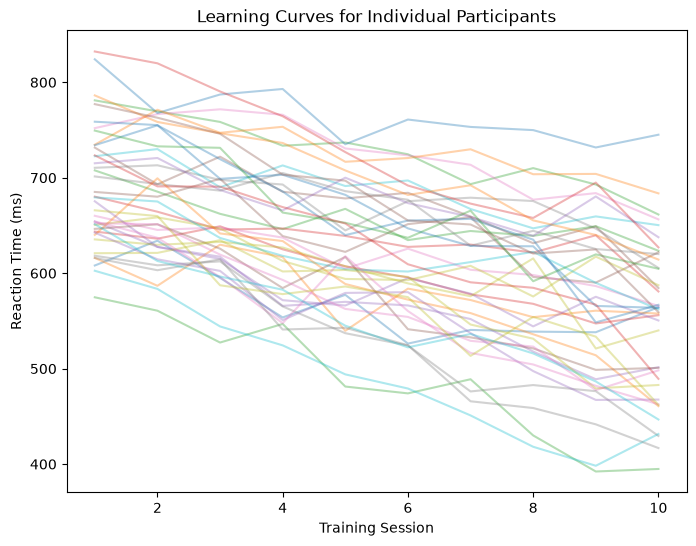

In [56]:
# Visualizing the learning curves.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for participant_id in data["participant"].unique():

    participant_data = data[
        data["participant"] == participant_id
    ]

    plt.plot(
        participant_data["session"],
        participant_data["reaction_time"],
        alpha=0.35
    )

plt.xlabel("Training Session")
plt.ylabel("Reaction Time (ms)")
plt.title("Learning Curves for Individual Participants")

plt.show()